# Лабораторная работа №1

## 1. Квадратичное программирование и QP-солвер

### Задание 1

In [1]:
from cvxopt import matrix, solvers

### Задание 2

In [2]:
P = matrix([[2.0, 0.0], [0.0, 8.0]])  # Матрица квадратичной части
q = matrix([-8.0, -16.0])  # Вектор линейной части

In [3]:
# Ограничения Gx <= h
G = matrix([[1.0, -1.0, 0.0, 1.0, 0.0], [1.0, 0.0, -1.0, 0.0, 1.0]])  # Ограничения
h = matrix([5.0, 0.0, 0.0, 3.0, 0.0])  # Вектор правой части ограничений

In [4]:
sol = solvers.qp(P, q, G, h)
print(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -3.0229e+01 -2.9783e+01  4e+01  1e+00  3e-01
 1: -2.1264e+01 -1.9688e+01  9e+00  2e-01  6e-02
 2: -1.4831e+01 -1.5186e+01  5e-01  3e-03  8e-04
 3: -1.4996e+01 -1.5003e+01  8e-03  3e-05  9e-06
 4: -1.5000e+01 -1.5000e+01  8e-05  3e-07  9e-08
 5: -1.5000e+01 -1.5000e+01  8e-07  3e-09  9e-10
Optimal solution found.
[ 3.00e+00]
[ 3.30e-09]



### Задание 3

Оптимумы: x<sub>1</sub> = 3, x<sub>2</sub> = 0. Подставив их в ограничения, получим, что x<sub>1</sub> и x<sub>2</sub> им удовлетворяют, следовательно, все ограничения активны. Значит, никакое выбросить нельзя, поскольку каждое влияет на результат.

## 2. Линейный SVM

Обучение модели происходит путем решения оптимизационной задачи:
$$
\begin{gather}
    \frac{1}{2} \| \boldsymbol w \|^2 + C \sum_{n=1}^N \xi_n \to \min_{\boldsymbol w, \boldsymbol \xi, b} \\
    \text{s.t.: } \quad y_n (\boldsymbol w^T \boldsymbol x_n + b) \geq 1 - \xi_n, \quad \xi_n \geq 0, \quad \forall n=1,\dots,N
\end{gather}
$$


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC

### Задание 1

In [10]:
# Определение функции для решения задачи квадратичного программирования SVM
def svm_qp_solver(X, y, C):
    N, d = X.shape
    
    # Матрица P: квадратичная часть (w^T w)
    P = matrix(np.block([[np.eye(d), np.zeros((d, N+1))], [np.zeros((N+1, d+N+1))]]))
    
    # Вектор q: линейная часть цели (C*sum(\xi))
    q = matrix(np.hstack([np.zeros(d+1), C * np.ones(N)]))
    
    # Ограничения Gx <= h
    G = np.hstack([-y[:, None] * X, -y[:, None], -np.eye(N)])
    G = matrix(np.vstack([G, np.hstack([np.zeros((N, d+1)), -np.eye(N)])]))
    h = matrix(np.hstack([-np.ones(N), np.zeros(N)]))
    
    # Решение задачи квадратичного программирования
    solution = solvers.qp(P, q, matrix(G), h)
    
    # Извлечение параметров
    w, b = np.array(solution['x'][:d]).flatten(), solution['x'][d]
    
    return w, b

### Задание 2

In [27]:
def convert_labels(y):
    return 2 * y - 1

# Генерация линейно разделимых данных
def generate_linearly_separable():
    X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=2.0, random_state=42)
    return X, convert_labels(y)

# Генерация хорошо разделимых, но нелинейных данных
def generate_non_linear():
    X, y = make_moons(n_samples=100, noise=0.1, random_state=42)
    return X, convert_labels(y)

# Генерация плохо разделимых данных
def generate_not_separable():
    X, y = make_blobs(n_samples=100, centers=2, cluster_std=2.0, random_state=42)
    return X, convert_labels(y)

### Задание 3

In [39]:
def plot_svm(X, y, w, b, C, title):
    plt.figure(figsize=(10, 8))
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

    decision_function = np.dot(X, w) + b
    support_vectors = np.abs(decision_function) <= 1 + 1e-6
    plt.scatter(X[support_vectors, 0], X[support_vectors, 1], facecolors='none', edgecolors='k', s=100, label='Опорные векторы')

    xlim = plt.xlim()
    ylim = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
    Z = np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b
    Z = Z.reshape(xx.shape)
    
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    plt.title(f'{title} (C={C})')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.legend()
    plt.show()

     pcost       dcost       gap    pres   dres
 0: -6.8669e-01  1.0691e+01  2e+02  2e+00  2e+02
 1:  8.8715e+00 -4.5038e+00  1e+01  4e-02  5e+00
 2:  1.4920e+00  3.7761e-02  1e+00  1e-03  2e-01
 3:  5.0639e-01  1.9526e-01  3e-01  3e-04  4e-02
 4:  3.1200e-01  2.2415e-01  9e-02  7e-05  9e-03
 5:  3.0969e-01  2.2892e-01  8e-02  5e-05  7e-03
 6:  2.8127e-01  2.3626e-01  5e-02  2e-05  2e-03
 7:  2.6488e-01  2.3899e-01  3e-02  5e-06  7e-04
 8:  2.6066e-01  2.4226e-01  2e-02  2e-06  3e-04
 9:  2.5366e-01  2.4548e-01  8e-03  5e-07  6e-05
10:  2.5021e-01  2.4727e-01  3e-03  1e-07  2e-05
11:  2.4848e-01  2.4833e-01  2e-04  3e-09  4e-07
12:  2.4840e-01  2.4840e-01  2e-06  3e-11  4e-09
13:  2.4840e-01  2.4840e-01  2e-08  3e-13  4e-11
Optimal solution found.


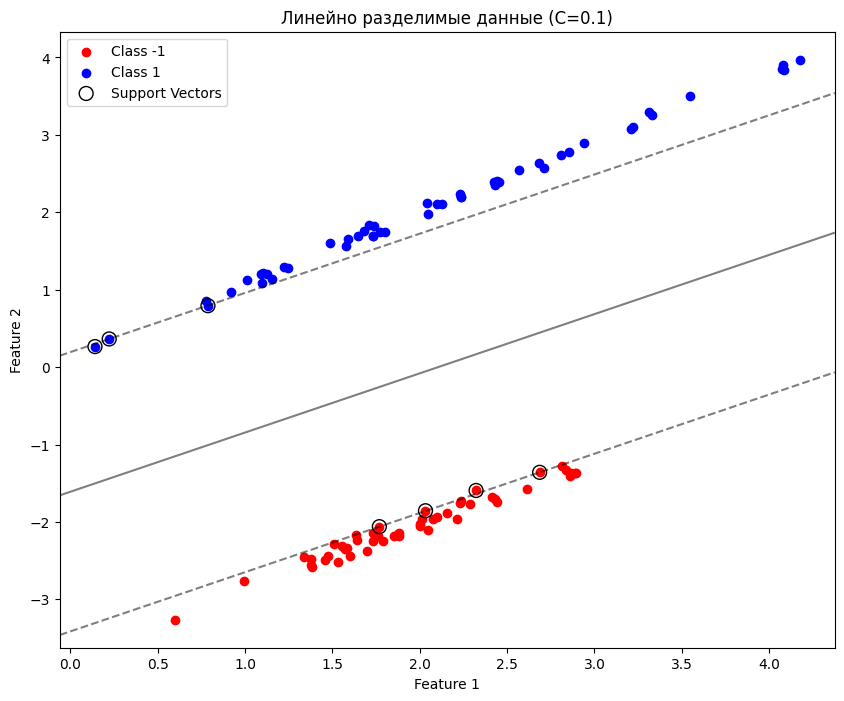

     pcost       dcost       gap    pres   dres
 0: -9.8135e+01  1.0727e+02  4e+02  3e+00  2e+01
 1:  2.6253e+01 -9.4873e+00  4e+01  1e-01  9e-01
 2:  1.6310e+00 -1.5387e-01  2e+00  9e-04  7e-03
 3:  3.8624e-01  1.9022e-01  2e-01  4e-05  3e-04
 4:  2.8586e-01  2.2493e-01  6e-02  6e-06  5e-05
 5:  2.8831e-01  2.2824e-01  6e-02  6e-06  4e-05
 6:  2.7221e-01  2.4145e-01  3e-02  1e-06  9e-06
 7:  2.5995e-01  2.4549e-01  1e-02  5e-07  4e-06
 8:  2.5704e-01  2.4851e-01  9e-03  4e-08  3e-07
 9:  2.5180e-01  2.5149e-01  3e-04  1e-09  8e-09
10:  2.5161e-01  2.5161e-01  3e-06  1e-11  8e-11
11:  2.5161e-01  2.5161e-01  3e-08  1e-13  8e-13
Optimal solution found.


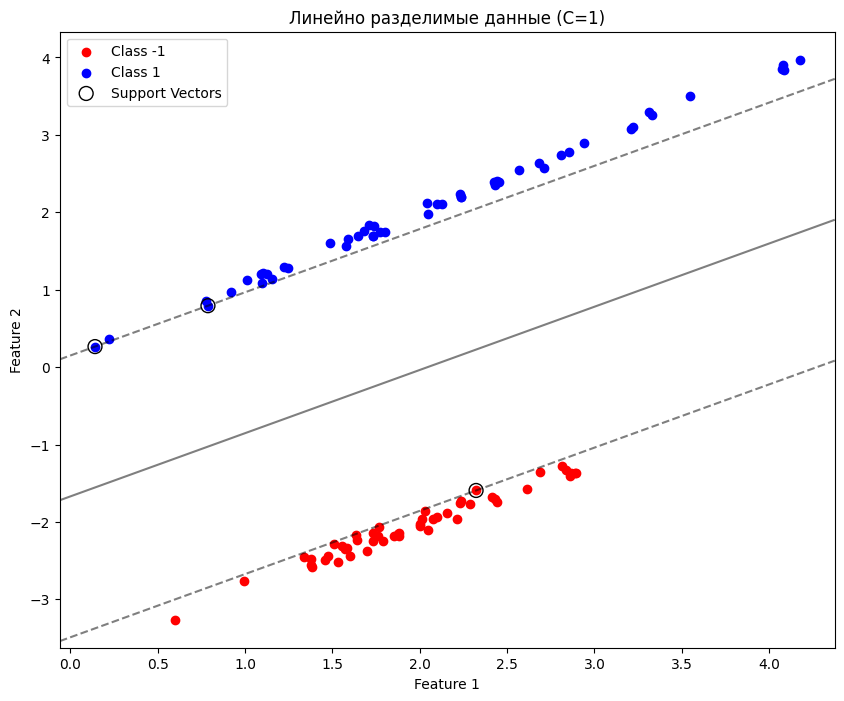

     pcost       dcost       gap    pres   dres
 0: -9.9185e+03  1.3709e+03  3e+03  2e+01  3e+00
 1: -6.1281e+02 -1.0655e+02  3e+02  1e+00  2e-01
 2:  4.8724e+00 -7.6859e+00  2e+01  9e-03  2e-03
 3:  1.9356e+00 -6.5313e-01  3e+00  1e-15  9e-16
 4:  4.8075e-01  1.4273e-01  3e-01  6e-16  4e-16
 5:  2.9838e-01  2.1488e-01  8e-02  3e-16  2e-16
 6:  2.7282e-01  2.3083e-01  4e-02  2e-16  2e-16
 7:  2.7233e-01  2.3912e-01  3e-02  1e-16  2e-16
 8:  2.5931e-01  2.4478e-01  1e-02  2e-16  3e-16
 9:  2.5840e-01  2.4802e-01  1e-02  2e-16  2e-16
10:  2.5207e-01  2.5127e-01  8e-04  2e-16  4e-16
11:  2.5162e-01  2.5161e-01  9e-06  2e-16  5e-16
12:  2.5161e-01  2.5161e-01  9e-08  2e-16  3e-16
Optimal solution found.


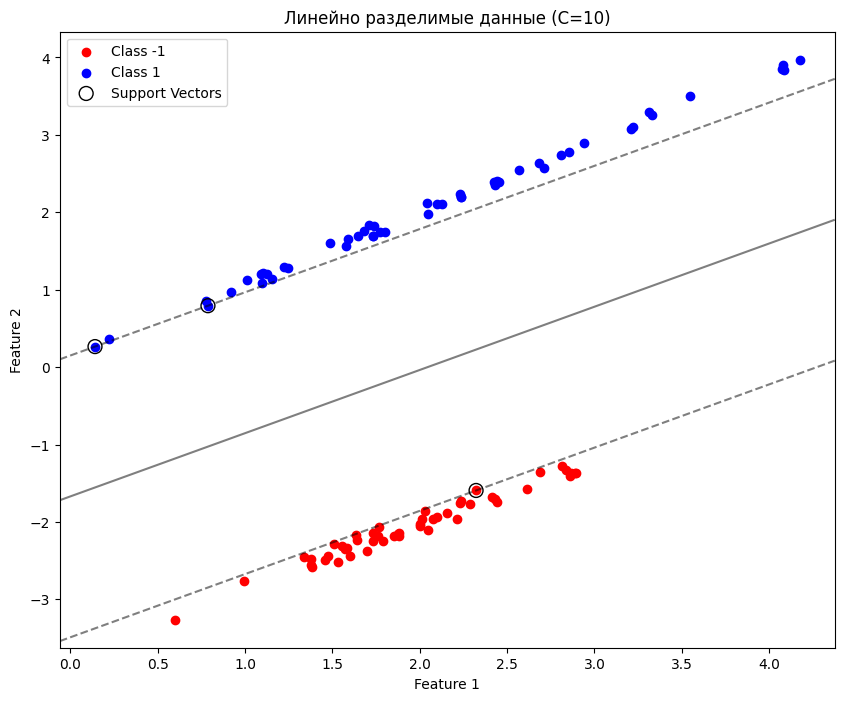

     pcost       dcost       gap    pres   dres
 0:  2.0156e+00  3.8027e+01  6e+02  3e+00  1e+02
 1:  1.9176e+01 -9.2461e-01  2e+01  2e-02  9e-01
 2:  6.0389e+00  3.6151e+00  2e+00  2e-03  9e-02
 3:  4.6831e+00  4.2429e+00  4e-01  2e-04  1e-02
 4:  4.5144e+00  4.4115e+00  1e-01  4e-05  2e-03
 5:  4.4710e+00  4.4463e+00  2e-02  1e-05  4e-04
 6:  4.4607e+00  4.4554e+00  5e-03  4e-07  2e-05
 7:  4.4580e+00  4.4578e+00  2e-04  1e-08  6e-07
 8:  4.4579e+00  4.4579e+00  1e-05  9e-10  4e-08
 9:  4.4579e+00  4.4579e+00  2e-06  6e-11  3e-09
Optimal solution found.


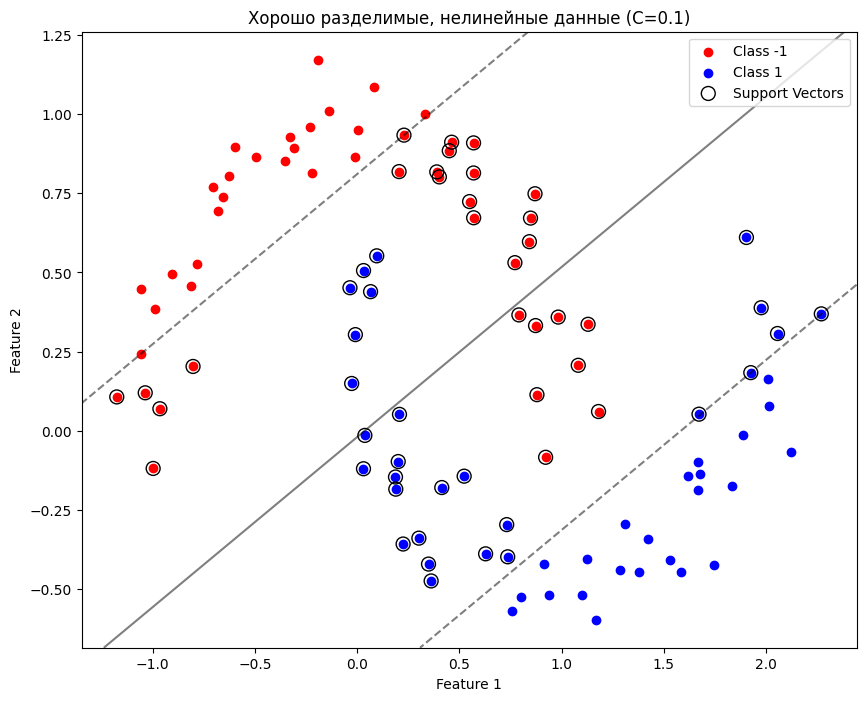

     pcost       dcost       gap    pres   dres
 0: -5.8092e+01  1.8936e+02  8e+02  4e+00  1e+01
 1:  1.0073e+02  6.3319e+00  1e+02  2e-01  4e-01
 2:  4.0013e+01  2.5427e+01  2e+01  2e-02  6e-02
 3:  3.3654e+01  3.0029e+01  4e+00  4e-03  1e-02
 4:  3.2283e+01  3.1190e+01  1e+00  8e-04  2e-03
 5:  3.1821e+01  3.1571e+01  3e-01  1e-04  3e-04
 6:  3.1686e+01  3.1674e+01  1e-02  2e-06  6e-06
 7:  3.1680e+01  3.1679e+01  1e-04  2e-08  6e-08
 8:  3.1680e+01  3.1680e+01  1e-06  2e-10  6e-10
Optimal solution found.


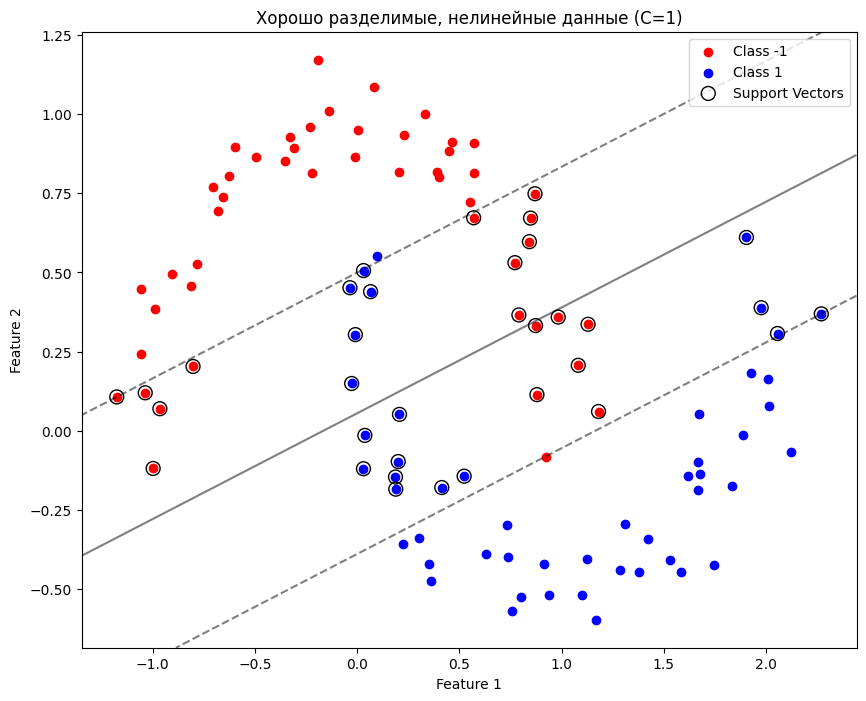

     pcost       dcost       gap    pres   dres
 0: -7.7661e+03  2.8528e+03  9e+03  2e+01  2e+00
 1:  7.8411e+02  1.0621e+02  8e+02  1e-01  1e-02
 2:  3.9495e+02  2.1069e+02  2e+02  3e-02  3e-03
 3:  3.3412e+02  2.4321e+02  1e+02  1e-02  1e-03
 4:  3.1865e+02  2.5617e+02  7e+01  7e-03  7e-04
 5:  3.0380e+02  2.6780e+02  4e+01  3e-03  3e-04
 6:  2.9923e+02  2.7122e+02  3e+01  2e-03  2e-04
 7:  2.8981e+02  2.8135e+02  9e+00  2e-04  2e-05
 8:  2.8791e+02  2.8241e+02  6e+00  8e-05  8e-06
 9:  2.8530e+02  2.8472e+02  6e-01  7e-06  7e-07
10:  2.8500e+02  2.8498e+02  2e-02  2e-07  2e-08
11:  2.8499e+02  2.8499e+02  2e-04  2e-09  2e-10
Optimal solution found.


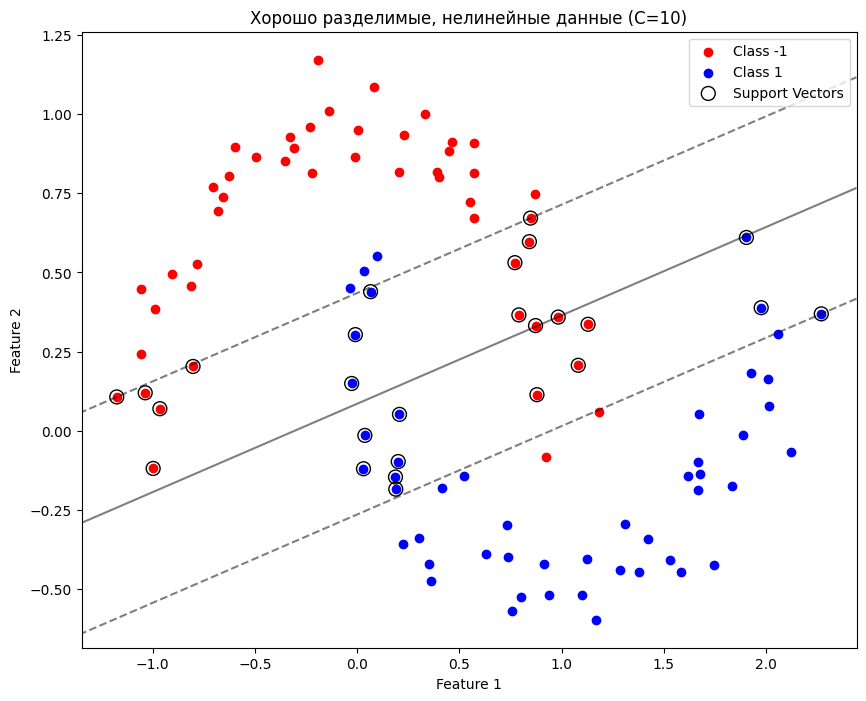

     pcost       dcost       gap    pres   dres
 0: -3.4133e-01  2.0798e+01  4e+02  2e+00  7e+02
 1:  1.2658e+01 -1.9122e+01  3e+01  1e-01  4e+01
 2:  4.5357e+00 -1.4599e+00  6e+00  1e-02  5e+00
 3:  8.7986e-01 -1.3932e-01  1e+00  2e-03  8e-01
 4:  3.3303e-01  7.9535e-02  3e-01  6e-04  2e-01
 5:  1.8009e-01  1.4041e-01  4e-02  3e-05  9e-03
 6:  1.6516e-01  1.5197e-01  1e-02  6e-06  2e-03
 7:  1.5839e-01  1.5736e-01  1e-03  2e-07  7e-05
 8:  1.5783e-01  1.5781e-01  1e-05  3e-09  9e-07
 9:  1.5782e-01  1.5782e-01  1e-07  3e-11  9e-09
Optimal solution found.


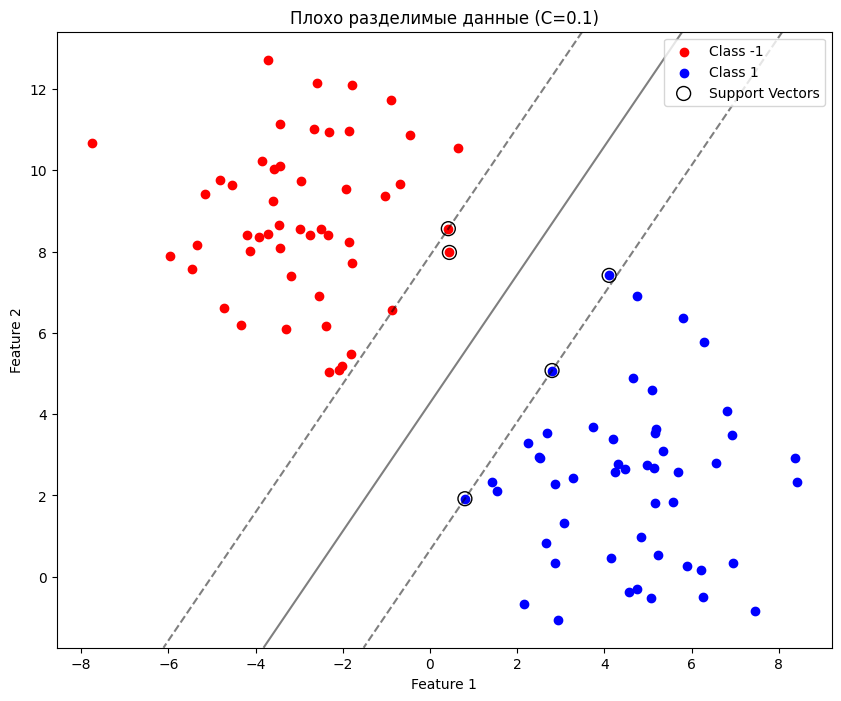

     pcost       dcost       gap    pres   dres
 0: -8.8319e+01  1.9208e+02  1e+03  4e+00  9e+01
 1:  6.7497e+01 -5.8086e+01  2e+02  5e-01  1e+01
 2:  9.2157e+00 -6.4064e+00  2e+01  5e-02  1e+00
 3:  6.3257e-01 -7.4061e-02  7e-01  8e-16  4e-16
 4:  2.7275e-01  5.2164e-02  2e-01  8e-16  3e-16
 5:  2.4333e-01  1.2701e-01  1e-01  5e-16  5e-16
 6:  1.7794e-01  1.6435e-01  1e-02  6e-16  3e-16
 7:  1.7014e-01  1.6992e-01  2e-04  5e-16  5e-15
 8:  1.7001e-01  1.7001e-01  2e-06  5e-16  1e-15
 9:  1.7001e-01  1.7001e-01  2e-08  6e-16  2e-15
Optimal solution found.


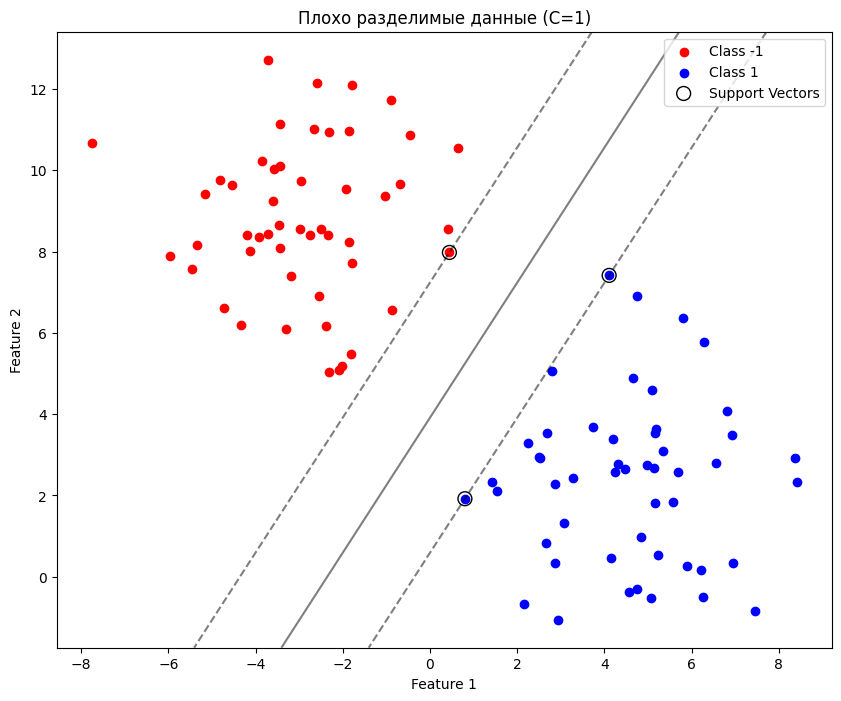

     pcost       dcost       gap    pres   dres
 0: -9.3592e+03  5.4911e+03  2e+04  2e+01  3e+01
 1:  4.5028e+01 -6.1124e+02  2e+03  2e+00  2e+00
 2:  1.4250e+01 -5.2558e+01  2e+02  1e-01  1e-01
 3:  3.6819e+00 -3.0740e+00  8e+00  1e-03  1e-03
 4:  6.9985e-01 -2.8000e-01  1e+00  2e-15  2e-16
 5:  1.9505e-01  3.8861e-02  2e-01  1e-15  4e-16
 6:  2.2396e-01  1.0653e-01  1e-01  6e-16  8e-16
 7:  1.8155e-01  1.5588e-01  3e-02  6e-16  3e-16
 8:  1.7032e-01  1.6973e-01  6e-04  6e-16  5e-16
 9:  1.7002e-01  1.7001e-01  6e-06  6e-16  3e-16
10:  1.7001e-01  1.7001e-01  6e-08  6e-16  2e-16
Optimal solution found.


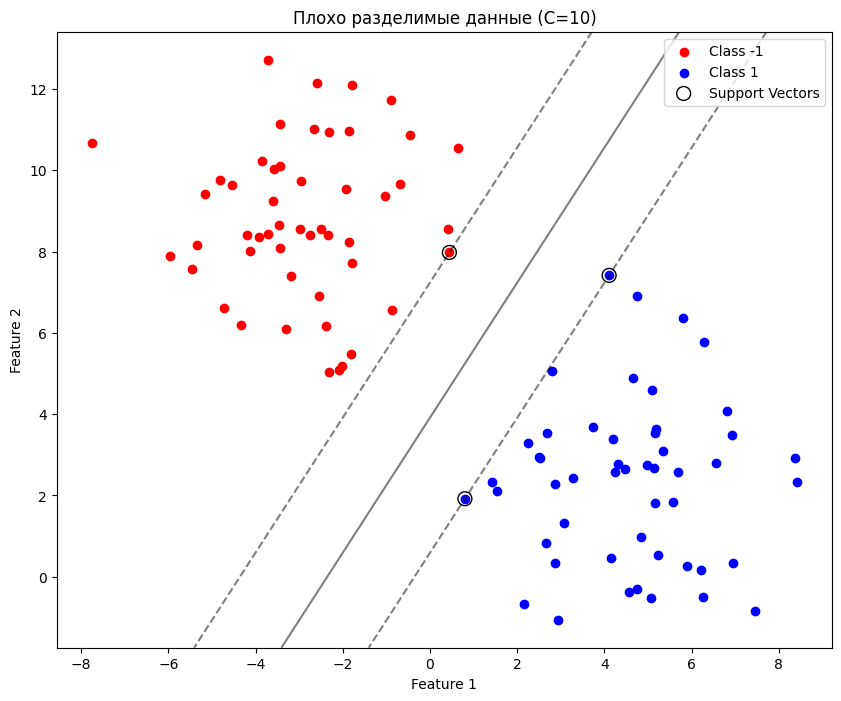

In [29]:
C_values = [0.1, 1, 10]
datasets = [
    (generate_linearly_separable(), 'Линейно разделимые данные'),
    (generate_non_linear(), 'Хорошо разделимые, нелинейные данные'),
    (generate_not_separable(), 'Плохо разделимые данные')
]

for (X, y), title in datasets:
    for C in C_values:
        w, b = svm_qp_solver(X, y, C)
        plot_svm(X, y, w, b, C, title)

### Задание 4

In [30]:
# Подсчет числа опорных векторов
def count_support_vectors(X, y, w, b, eps=1e-6):
    decision_function = np.dot(X, w) + b
    return np.sum(np.abs(decision_function) <= 1 + eps)

     pcost       dcost       gap    pres   dres
 0: -6.8669e-01  1.0691e+01  2e+02  2e+00  2e+02
 1:  8.8715e+00 -4.5038e+00  1e+01  4e-02  5e+00
 2:  1.4920e+00  3.7761e-02  1e+00  1e-03  2e-01
 3:  5.0639e-01  1.9526e-01  3e-01  3e-04  4e-02
 4:  3.1200e-01  2.2415e-01  9e-02  7e-05  9e-03
 5:  3.0969e-01  2.2892e-01  8e-02  5e-05  7e-03
 6:  2.8127e-01  2.3626e-01  5e-02  2e-05  2e-03
 7:  2.6488e-01  2.3899e-01  3e-02  5e-06  7e-04
 8:  2.6066e-01  2.4226e-01  2e-02  2e-06  3e-04
 9:  2.5366e-01  2.4548e-01  8e-03  5e-07  6e-05
10:  2.5021e-01  2.4727e-01  3e-03  1e-07  2e-05
11:  2.4848e-01  2.4833e-01  2e-04  3e-09  4e-07
12:  2.4840e-01  2.4840e-01  2e-06  3e-11  4e-09
13:  2.4840e-01  2.4840e-01  2e-08  3e-13  4e-11
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -9.8135e+01  1.0727e+02  4e+02  3e+00  2e+01
 1:  2.6253e+01 -9.4873e+00  4e+01  1e-01  9e-01
 2:  1.6310e+00 -1.5387e-01  2e+00  9e-04  7e-03
 3:  3.8624e-01  1.9022e-01  2e-01  4e-05  3e-0

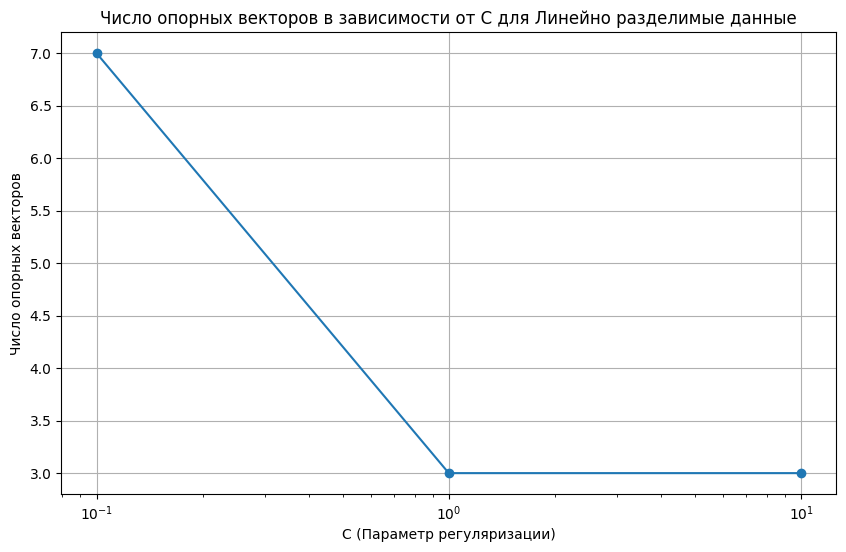

     pcost       dcost       gap    pres   dres
 0:  2.0156e+00  3.8027e+01  6e+02  3e+00  1e+02
 1:  1.9176e+01 -9.2461e-01  2e+01  2e-02  9e-01
 2:  6.0389e+00  3.6151e+00  2e+00  2e-03  9e-02
 3:  4.6831e+00  4.2429e+00  4e-01  2e-04  1e-02
 4:  4.5144e+00  4.4115e+00  1e-01  4e-05  2e-03
 5:  4.4710e+00  4.4463e+00  2e-02  1e-05  4e-04
 6:  4.4607e+00  4.4554e+00  5e-03  4e-07  2e-05
 7:  4.4580e+00  4.4578e+00  2e-04  1e-08  6e-07
 8:  4.4579e+00  4.4579e+00  1e-05  9e-10  4e-08
 9:  4.4579e+00  4.4579e+00  2e-06  6e-11  3e-09
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -5.8092e+01  1.8936e+02  8e+02  4e+00  1e+01
 1:  1.0073e+02  6.3319e+00  1e+02  2e-01  4e-01
 2:  4.0013e+01  2.5427e+01  2e+01  2e-02  6e-02
 3:  3.3654e+01  3.0029e+01  4e+00  4e-03  1e-02
 4:  3.2283e+01  3.1190e+01  1e+00  8e-04  2e-03
 5:  3.1821e+01  3.1571e+01  3e-01  1e-04  3e-04
 6:  3.1686e+01  3.1674e+01  1e-02  2e-06  6e-06
 7:  3.1680e+01  3.1679e+01  1e-04  2e-08  6e-0

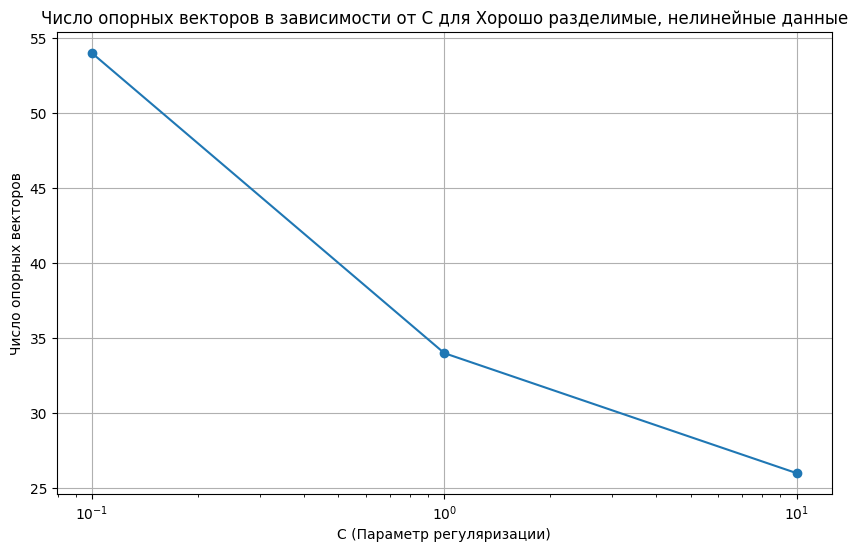

     pcost       dcost       gap    pres   dres
 0: -3.4133e-01  2.0798e+01  4e+02  2e+00  7e+02
 1:  1.2658e+01 -1.9122e+01  3e+01  1e-01  4e+01
 2:  4.5357e+00 -1.4599e+00  6e+00  1e-02  5e+00
 3:  8.7986e-01 -1.3932e-01  1e+00  2e-03  8e-01
 4:  3.3303e-01  7.9535e-02  3e-01  6e-04  2e-01
 5:  1.8009e-01  1.4041e-01  4e-02  3e-05  9e-03
 6:  1.6516e-01  1.5197e-01  1e-02  6e-06  2e-03
 7:  1.5839e-01  1.5736e-01  1e-03  2e-07  7e-05
 8:  1.5783e-01  1.5781e-01  1e-05  3e-09  9e-07
 9:  1.5782e-01  1.5782e-01  1e-07  3e-11  9e-09
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -8.8319e+01  1.9208e+02  1e+03  4e+00  9e+01
 1:  6.7497e+01 -5.8086e+01  2e+02  5e-01  1e+01
 2:  9.2157e+00 -6.4064e+00  2e+01  5e-02  1e+00
 3:  6.3257e-01 -7.4061e-02  7e-01  8e-16  4e-16
 4:  2.7275e-01  5.2164e-02  2e-01  8e-16  3e-16
 5:  2.4333e-01  1.2701e-01  1e-01  5e-16  5e-16
 6:  1.7794e-01  1.6435e-01  1e-02  6e-16  3e-16
 7:  1.7014e-01  1.6992e-01  2e-04  5e-16  5e-1

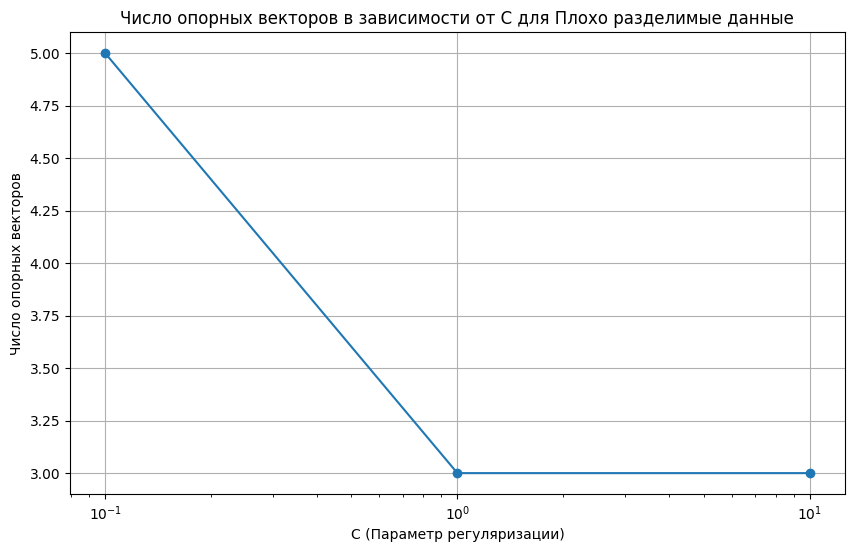

In [38]:
# Исследование зависимости числа опорных векторов от C
for (X, y), title in datasets:
    num_support_vectors = []
    for C in C_values:
        w, b = svm_qp_solver(X, y, C)
        num_sv = count_support_vectors(X, y, w, b)
        num_support_vectors.append(num_sv)
    
    plt.figure(figsize=(10, 6))
    plt.plot(C_values, num_support_vectors, marker='o')
    plt.xscale('log')
    plt.xlabel('C (Параметр регуляризации)')
    plt.ylabel('Число опорных векторов')
    plt.title(f'Число опорных векторов в зависимости от C для {title}')
    plt.grid(True)
    plt.show()

### Задание 5

In [32]:
# Преобразование признаков в квадратичные
def transform_features(X):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    return poly.fit_transform(X)

In [33]:
# Обучение SVM с квадратичными признаками
def train_svm_with_transformed_features(X, y, C):
    X_transformed = transform_features(X)
    svm = SVC(C=C, kernel='linear')
    svm.fit(X_transformed, y)
    return svm

In [41]:
# Визуализация разделяющей поверхности
def plot_decision_boundary(svm, X, y, C, title):
    X_transformed = transform_features(X)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

    xlim = plt.xlim()
    ylim = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_transformed = transform_features(grid)
    Z = svm.decision_function(grid_transformed)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=['red', 'blue'])
    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    
    plt.title(f'Пространство квадратичного SVM (C={C}) для {title}')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.legend()
    plt.show()

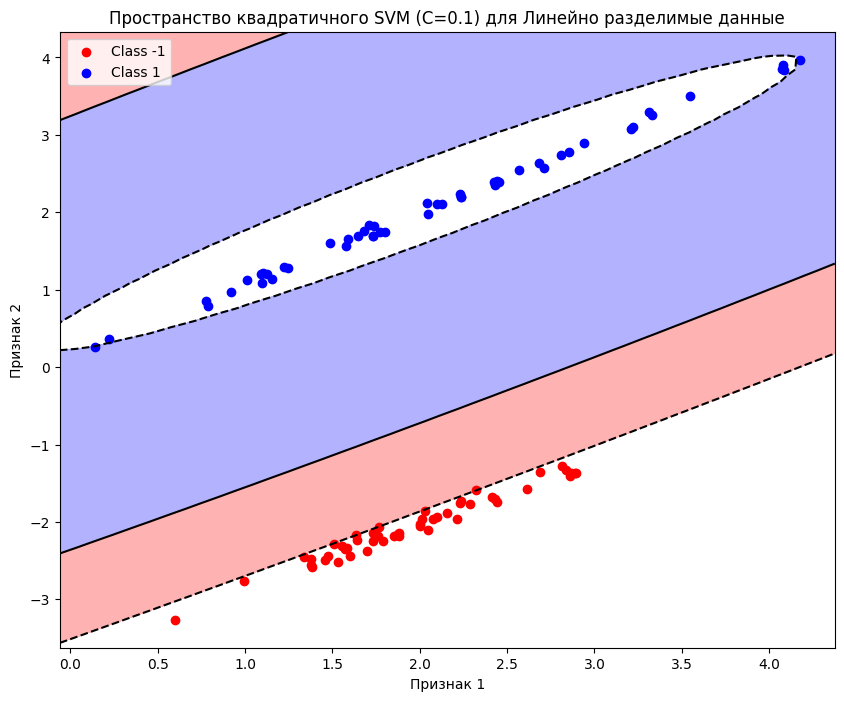

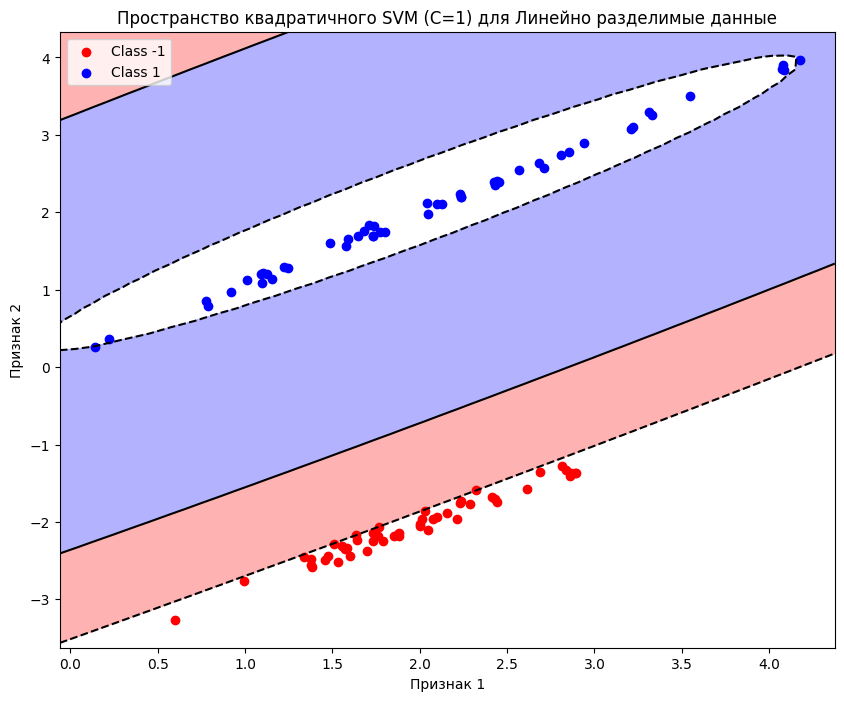

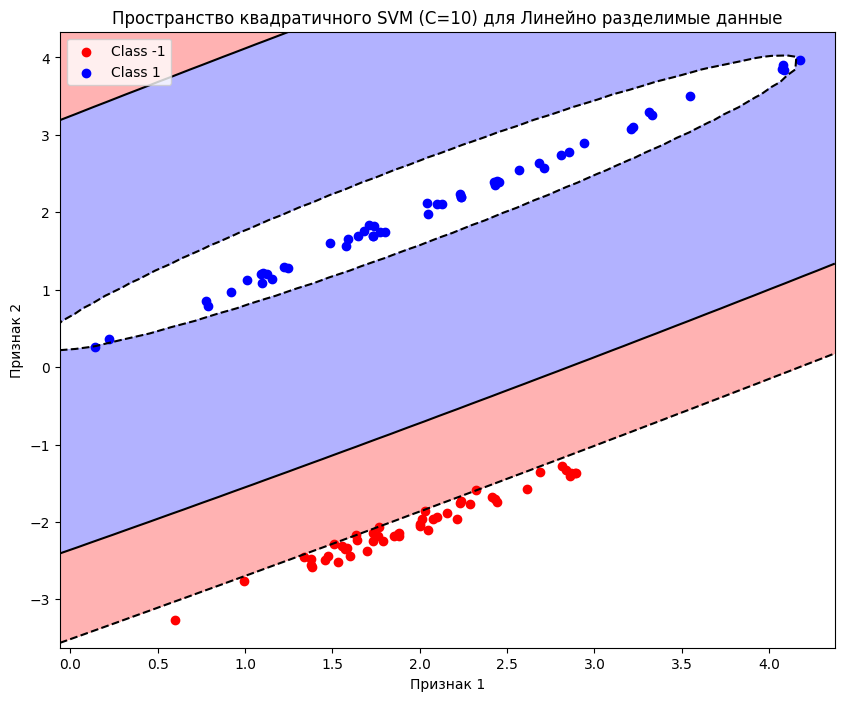

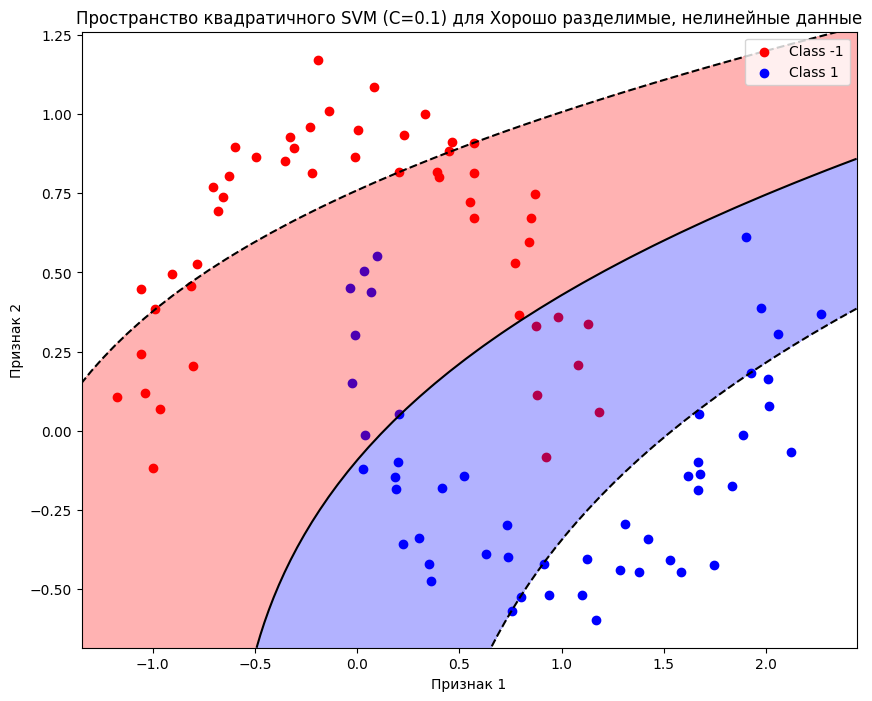

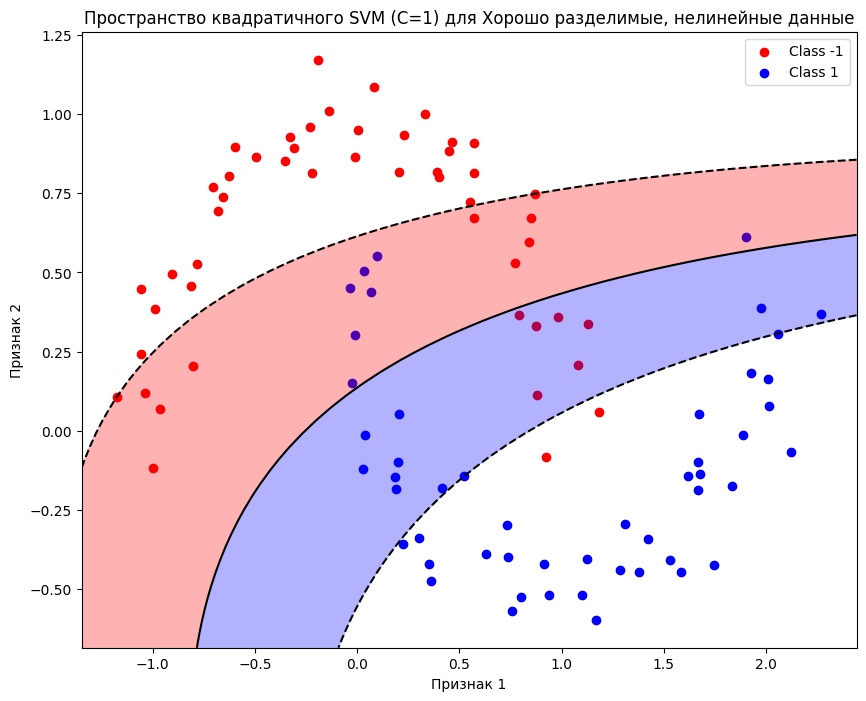

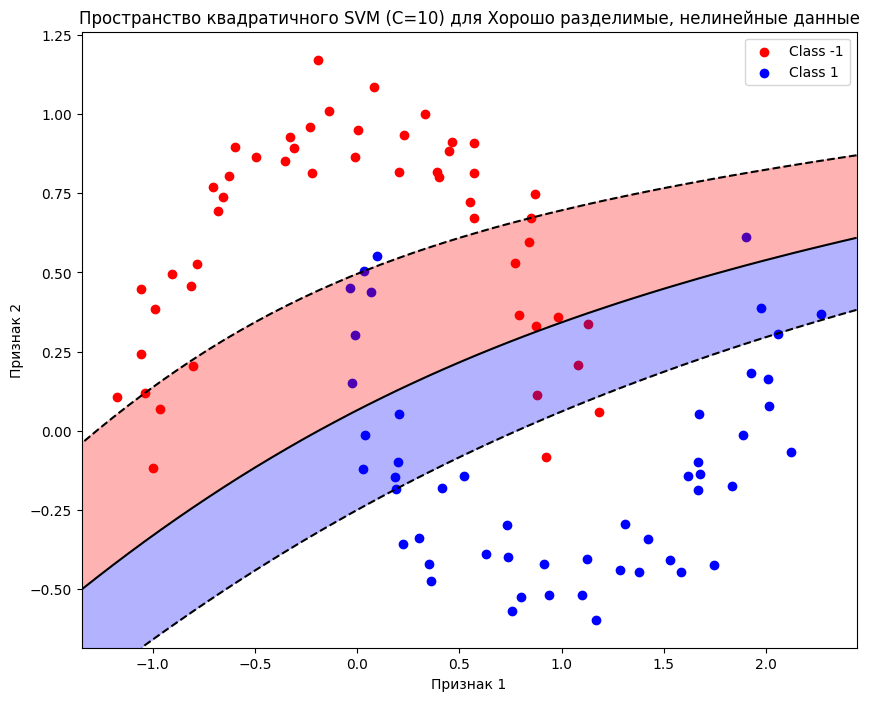

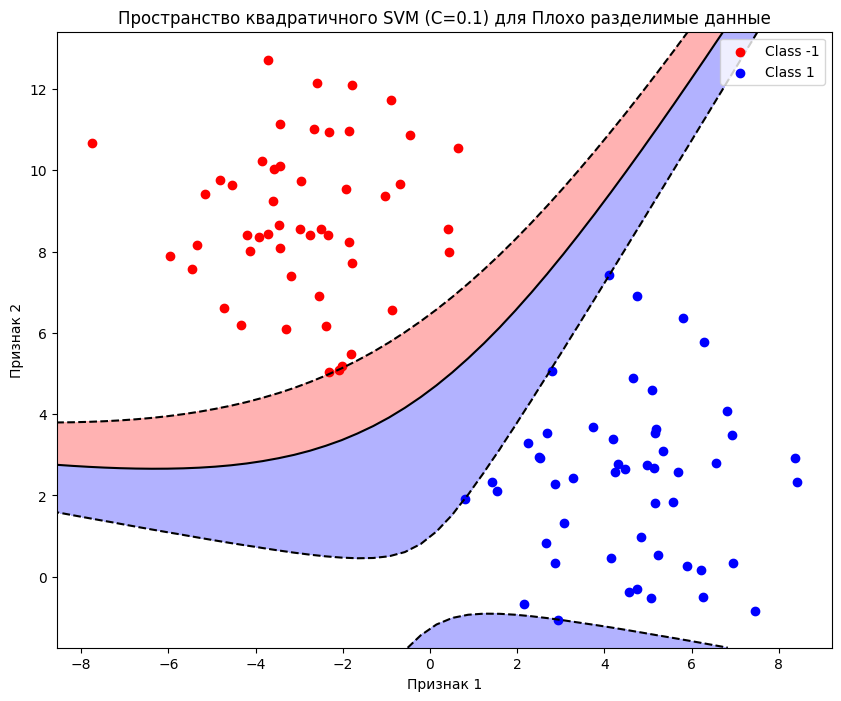

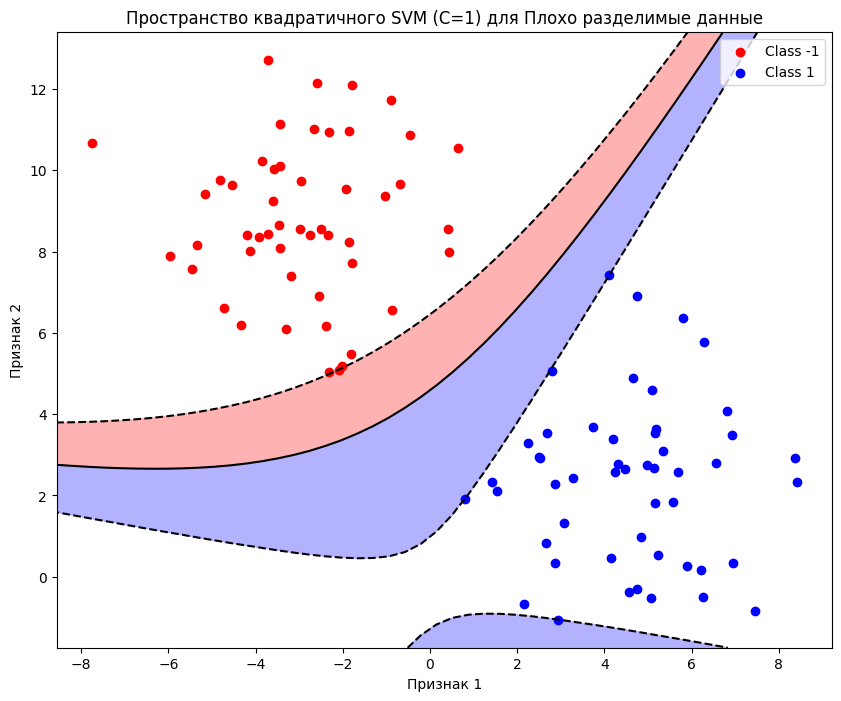

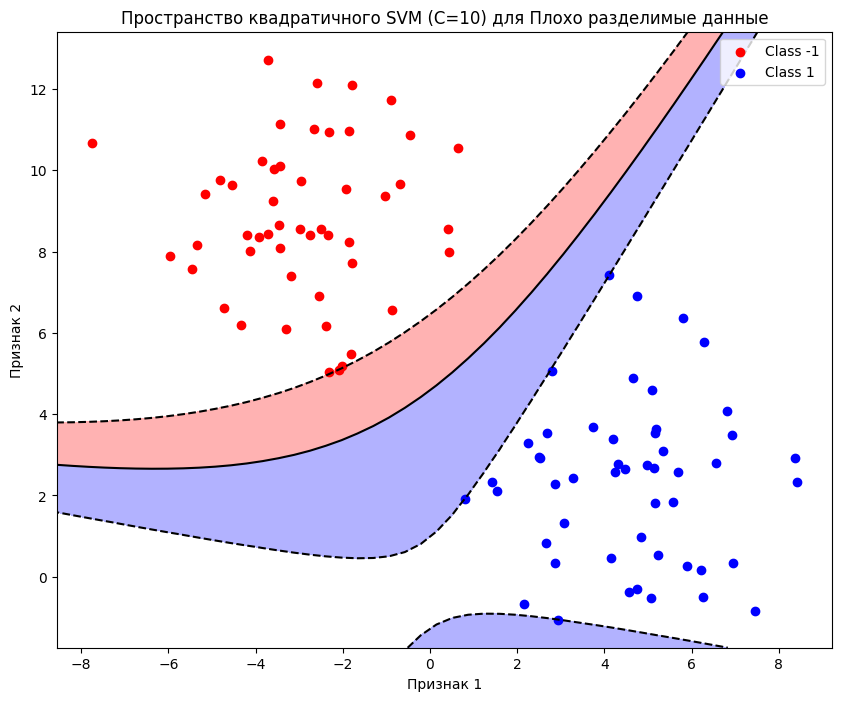

In [42]:
# Обучение и визуализация для разных наборов данных и значений C
for (X, y), title in datasets:
    for C in C_values:
        svm = train_svm_with_transformed_features(X, y, C)
        plot_decision_boundary(svm, X, y, C, title)

## 3. Двойственный переход и Ядровой SVM

### Задание 1

In [43]:
# Ядерные функции
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x1, x2, p=3):
    return (np.dot(x1, x2) + 1) ** p

def rbf_kernel(x1, x2, gamma=0.5):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

In [44]:
# Построение матрицы Грамма для любого ядра
def compute_gram_matrix(X, kernel_func, **kernel_params):
    N = X.shape[0]
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            K[i, j] = kernel_func(X[i], X[j], **kernel_params)
    return K

In [45]:
# Решение двойственной задачи
def kernel_svm_qp_solver(X, y, kernel_func, C, **kernel_params):
    N = X.shape[0]
    K = compute_gram_matrix(X, kernel_func, **kernel_params)
    
    P = matrix(np.outer(y, y) * K)
    q = matrix(-np.ones(N))
    G = matrix(np.vstack([-np.eye(N), np.eye(N)]))
    h = matrix(np.hstack([np.zeros(N), C * np.ones(N)]))
    A = matrix(y, (1, N), 'd')
    b = matrix(0.0)
    
    sol = solvers.qp(P, q, G, h, A, b)
    alphas = np.ravel(sol['x'])
    
    # Опорные вектора: те, у которых альфа > 0
    sv = alphas > 1e-5
    indices = np.arange(len(alphas))[sv]
    alphas = alphas[sv]
    sv_X = X[sv]
    sv_y = y[sv]
    
    # Вычисление смещения b
    b = np.mean([sv_y[i] - np.sum(alphas * sv_y * K[indices[i], sv]) for i in range(len(alphas))])
    
    return alphas, sv_X, sv_y, b

In [46]:
# Предсказание
def predict(X, alphas, sv_X, sv_y, b, kernel_func, **kernel_params):
    y_pred = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        pred = sum(alphas[j] * sv_y[j] * kernel_func(X[i], sv_X[j], **kernel_params) for j in range(len(sv_X)))
        y_pred[i] = pred + b
    return np.sign(y_pred)

### Задание 2

In [50]:
# Функция для визуализации разделяющей поверхности
def plot_decision_boundary(X, y, alphas, sv_X, sv_y, b, kernel_func, **kernel_params):
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')
    
    # Построение сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid, alphas, sv_X, sv_y, b, kernel_func, **kernel_params)
    Z = Z.reshape(xx.shape)
    
    # Построение линий уровня
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    
    # Отображение опорных векторов
    plt.scatter(sv_X[:, 0], sv_X[:, 1], s=100, facecolors='none', edgecolors='k', label='Опорные векторы')
    plt.legend()
    plt.show()

In [48]:
# Генерация данных
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)
y = 2*y - 1  # Преобразование меток к {-1, 1}

     pcost       dcost       gap    pres   dres
 0: -3.6165e+01 -1.9510e+02  8e+02  2e+00  2e-15
 1: -2.4068e+01 -1.1188e+02  1e+02  1e-01  1e-15
 2: -2.6514e+01 -4.1615e+01  2e+01  1e-02  1e-15
 3: -3.0176e+01 -3.3929e+01  4e+00  2e-03  1e-15
 4: -3.1220e+01 -3.2341e+01  1e+00  5e-04  2e-15
 5: -3.1575e+01 -3.1829e+01  3e-01  7e-05  1e-15
 6: -3.1674e+01 -3.1686e+01  1e-02  1e-06  2e-15
 7: -3.1679e+01 -3.1680e+01  1e-04  1e-08  1e-15
 8: -3.1680e+01 -3.1680e+01  1e-06  1e-10  2e-15
Optimal solution found.


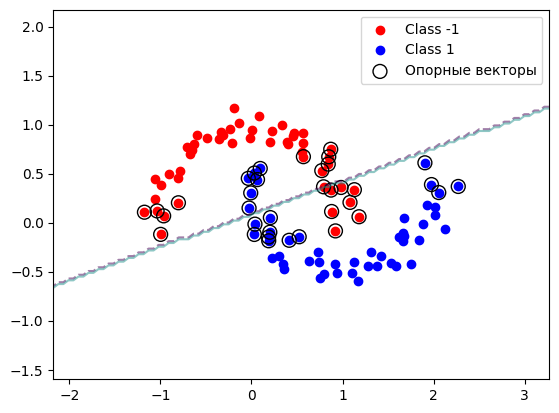

     pcost       dcost       gap    pres   dres
 0: -1.7383e+01 -2.0078e+02  1e+03  3e+00  2e-14
 1: -9.8070e+00 -1.1728e+02  2e+02  3e-01  2e-14
 2: -6.2085e+00 -3.2628e+01  3e+01  4e-02  1e-14
 3: -7.4731e+00 -1.6290e+01  1e+01  1e-02  1e-14
 4: -8.6784e+00 -1.2886e+01  4e+00  2e-03  4e-15
 5: -9.8127e+00 -1.0538e+01  7e-01  7e-05  6e-15
 6: -1.0042e+01 -1.0100e+01  6e-02  5e-06  6e-15
 7: -1.0062e+01 -1.0067e+01  5e-03  4e-07  6e-15
 8: -1.0063e+01 -1.0063e+01  2e-04  9e-09  7e-15
 9: -1.0063e+01 -1.0063e+01  5e-06  1e-10  8e-15
Optimal solution found.


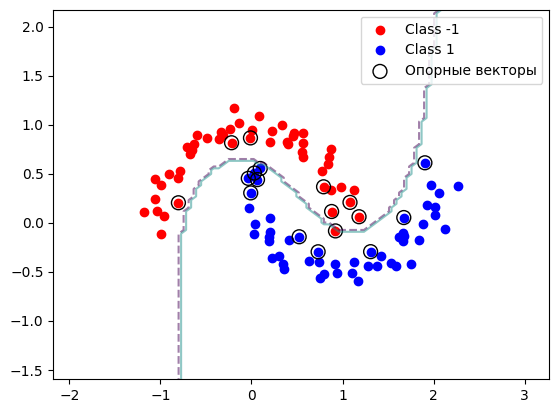

     pcost       dcost       gap    pres   dres
 0: -2.2030e+01 -1.8746e+02  7e+02  2e+00  1e-15
 1: -1.6745e+01 -1.0342e+02  9e+01  7e-16  1e-15
 2: -2.0207e+01 -3.3968e+01  1e+01  2e-16  1e-15
 3: -2.2258e+01 -2.8004e+01  6e+00  2e-15  8e-16
 4: -2.3238e+01 -2.5576e+01  2e+00  2e-15  8e-16
 5: -2.3731e+01 -2.4448e+01  7e-01  4e-16  1e-15
 6: -2.3932e+01 -2.4071e+01  1e-01  3e-15  1e-15
 7: -2.3980e+01 -2.3990e+01  1e-02  4e-16  9e-16
 8: -2.3984e+01 -2.3984e+01  1e-04  3e-16  1e-15
 9: -2.3984e+01 -2.3984e+01  1e-06  1e-15  1e-15
Optimal solution found.


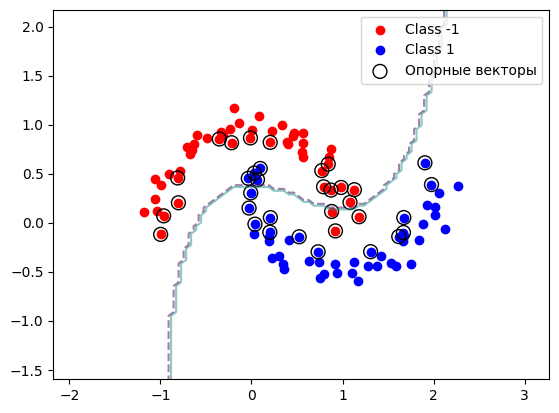

In [51]:
# Обучение с линейным ядром
alphas, sv_X, sv_y, b = kernel_svm_qp_solver(X, y, linear_kernel, C=1.0)
plot_decision_boundary(X, y, alphas, sv_X, sv_y, b, linear_kernel)

# Обучение с полиномиальным ядром (p=3)
alphas, sv_X, sv_y, b = kernel_svm_qp_solver(X, y, polynomial_kernel, C=1.0, p=3)
plot_decision_boundary(X, y, alphas, sv_X, sv_y, b, polynomial_kernel, p=3)

# Обучение с RBF ядром
alphas, sv_X, sv_y, b = kernel_svm_qp_solver(X, y, rbf_kernel, C=1.0, gamma=0.5)
plot_decision_boundary(X, y, alphas, sv_X, sv_y, b, rbf_kernel, gamma=0.5)

### Задание 3

Полиномиальное ядро становится более гибким с увеличением степени p. При больших значениях p модель может чрезмерно подстраиваться под обучающие данные (т.е. переобучение), особенно при больших значениях C, что контролирует штраф за ошибки классификации.

### Задание 4

Для радиального базисного ядра малые значения 𝛾 приводят к сглаживанию разделяющей поверхности, а большие — к увеличению гибкости модели. При слишком больших значениях γ модель может переобучиться, особенно при высоких значениях C.